In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as shc
from sklearn.preprocessing import normalize
import os

# Fijamos tu ruta 
ruta = r"C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 5 Aprendizaje de máquina no supervisado\MOD 1 Algoritmo Clustering Jerárquico"
os.chdir(ruta)

# Cargamos los datos usando read_excel y la columna 0 (nombres) como índice
df_amazon = pd.read_excel('Amazon.xlsx', index_col=0)

# Le ponemos un nombre bonito al índice
df_amazon.index.name = 'Cliente'

# Vemos las primeras 5 filas para comprobar que todo está bien
display(df_amazon.head())

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
Cliente,,,,,,,,,
Adam,205,3,345,235,24,23,26,21,17
Anna,9,15,315,33,25,4,42,215,28
Bernard,17,26,285,3,43,27,41,26,33
Edward,135,5,355,295,18,23,39,195,17
Emilia,3,45,48,39,34,46,225,34,43


In [5]:
from sklearn.preprocessing import normalize

# 1. Normalizamos los datos
# RELLENA AQUÍ: pon el nombre de tu tabla de datos
datos_escalados_array = normalize(df_amazon) 

# 2. Lo volvemos a convertir en una tabla (DataFrame) para no perder los nombres de las columnas ni de los clientes
df_escalado = pd.DataFrame(datos_escalados_array, columns=df_amazon.columns, index=df_amazon.index)

# 3. Vemos la magia
display(df_escalado.head())

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
Cliente,,,,,,,,,
Adam,0.438263,0.006414,0.737565,0.502399,0.051309,0.049171,0.055585,0.044895,0.036344
Anna,0.023235,0.038725,0.813234,0.085196,0.064542,0.010327,0.108431,0.555065,0.072287
Bernard,0.057235,0.087535,0.959520,0.010100,0.144770,0.090902,0.138036,0.087535,0.111102
Edward,0.258856,0.009587,0.680696,0.565649,0.034514,0.044101,0.074781,0.373904,0.032597
Emilia,0.011975,0.179625,0.191600,0.155675,0.135717,0.183617,0.898127,0.135717,0.171642


In [8]:
from sklearn.preprocessing import normalize

# 1. Normalizamos los datos
# RELLENA AQUÍ: pon el nombre de tu tabla de datos
datos_escalados_array = normalize(df_amazon) 

# 2. Lo volvemos a convertir en una tabla (DataFrame) para no perder los nombres de las columnas ni de los clientes
df_escalado = pd.DataFrame(datos_escalados_array, columns=df_amazon.columns, index=df_amazon.index)

# 3. Vemos la magia
display(df_escalado.head())

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
Cliente,,,,,,,,,
Adam,0.438263,0.006414,0.737565,0.502399,0.051309,0.049171,0.055585,0.044895,0.036344
Anna,0.023235,0.038725,0.813234,0.085196,0.064542,0.010327,0.108431,0.555065,0.072287
Bernard,0.057235,0.087535,0.959520,0.010100,0.144770,0.090902,0.138036,0.087535,0.111102
Edward,0.258856,0.009587,0.680696,0.565649,0.034514,0.044101,0.074781,0.373904,0.032597
Emilia,0.011975,0.179625,0.191600,0.155675,0.135717,0.183617,0.898127,0.135717,0.171642


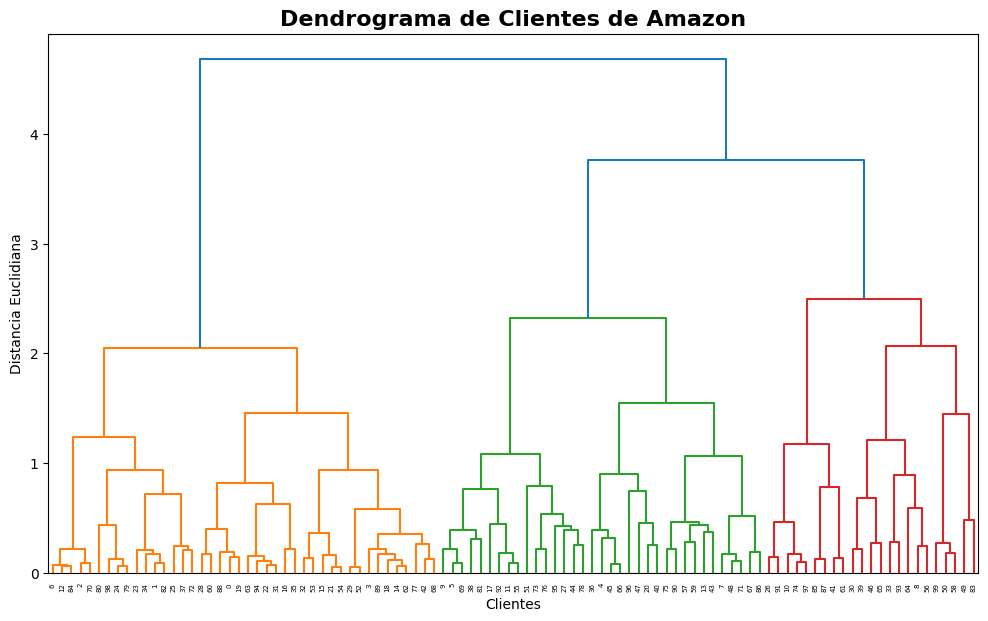

In [9]:
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plt.title("Dendrograma de Clientes de Amazon", fontsize=16, fontweight='bold')

# Código completo: le pasamos "df_escalado" y el método "ward"
dendrograma = shc.dendrogram(shc.linkage(df_escalado, method='ward'))

plt.xlabel('Clientes')
plt.ylabel('Distancia Euclidiana')
plt.show()

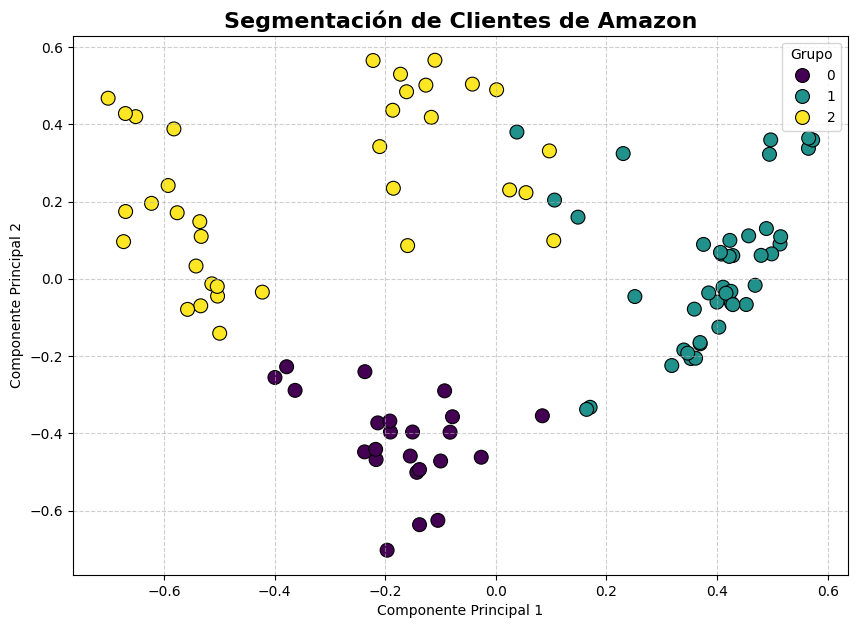


--- RECOMENDACIONES PARA EL REPORTE ---
Recomendaría a Salome los mismos productos que compraron: Emilia, Fabian y Frank (Todos pertenecen al Grupo 2).
Recomendaría a Stephan los mismos productos que compraron: Adam, Anna y Bernard (Todos pertenecen al Grupo 1).
Recomendaría a Lydia los mismos productos que compraron: Adam, Anna y Bernard (Todos pertenecen al Grupo 1).


In [11]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# --- PASO 4: CREAR LOS 3 GRUPOS ---
# Le decimos al modelo que queremos 3 grupos (basado en nuestro dendrograma)
modelo_hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

# Entrenamos y le asignamos un grupo (0, 1 o 2) a cada cliente
grupos_amazon = modelo_hc.fit_predict(df_escalado)

# Guardamos ese número de grupo en nuestra tabla original
df_amazon['Grupo'] = grupos_amazon


# --- PASO 5: GRÁFICO PCA PARA EL REPORTE ---
# Comprimimos a 2 dimensiones para graficar
pca = PCA(n_components=2)
datos_pca = pca.fit_transform(df_escalado)

# Dibujamos el gráfico
plt.figure(figsize=(10, 7))
sns.scatterplot(x=datos_pca[:, 0], y=datos_pca[:, 1], hue=grupos_amazon, palette='viridis', s=100, edgecolor='k')

plt.title('Segmentación de Clientes de Amazon', fontsize=16, fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Grupo')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# --- RESPUESTAS EXACTAS PARA TU RÚBRICA ---
print("\n--- RECOMENDACIONES PARA EL REPORTE ---")

# Quitamos cualquier espacio en blanco fantasma que traiga el Excel por error
df_amazon.index = df_amazon.index.str.strip()

# Usamos fragmentos para no pelear con las tildes del Excel
busquedas = ['Salom', 'Stephan', 'Lydia']

for busqueda in busquedas:
    # Filtramos la tabla para encontrar el nombre real sin importar mayúsculas o tildes
    nombres_reales = [nombre for nombre in df_amazon.index if busqueda.lower() in str(nombre).lower()]
    
    if len(nombres_reales) > 0:
        cliente_real = nombres_reales[0] # Tomamos el nombre exacto como viene en tu Excel
        
        # Vemos en qué grupo cayó
        grupo_cliente = df_amazon.loc[cliente_real, 'Grupo']
        
        # Buscamos a otros clientes en ese mismo grupo
        similares = df_amazon[df_amazon['Grupo'] == grupo_cliente].index.tolist()
        similares.remove(cliente_real) # Quitamos al cliente de su propia lista
        
        # Imprimimos la recomendación tomando a 3 personas de ejemplo
        print(f"Recomendaría a {cliente_real} los mismos productos que compraron: {similares[0]}, {similares[1]} y {similares[2]} (Todos pertenecen al Grupo {grupo_cliente}).")
    else:
        print(f"Ojo: No encontré a nadie parecido a '{busqueda}' en tu archivo de Excel.")